<a href="https://colab.research.google.com/github/Ranveer-Panesar/Week2_Project/blob/main/Week2_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction Project: Workflow & Analysis

## Project Overview
This project provides a comprehensive machine learning analysis of the **Heart Disease UCI** dataset, covering the full pipeline from raw data acquisition to model interpretation.

## 🛠 Project Highlights & Workflow

### 1. Data Acquisition & Cleaning
- **Source:** Kaggle (`heart-disease-data`).
- **Feature Selection:** The column `ca` was dropped due to high sparsity (~65% missing values).
- **Imputation Strategy:**
    - **Categorical:** Mode imputation for `slope`, `thal`, `fbs`, `restecg`, and `exang`.
    - **Numerical:** Median imputation for `oldpeak`, `chol`, `trestbps`, and `thalch`.
- **Encoding:** Applied **Label Encoding** for binary features and **One-Hot Encoding** for multi-categorical features to prepare data for tree-based models.

### 2. Modeling Strategy: Tree vs. Forest
We compared a single **Decision Tree** against a **Random Forest (100 estimators)** to evaluate the benefits of ensemble learning.
- **Performance Comparison:**
    - **Random Forest:** ~60% Accuracy. More robust and better at generalizing across classes.
    - **Decision Tree:** ~51% Accuracy. Useful for interpretability but prone to lower accuracy in this multiclass setting.
- **Observation:** Both models excel at identifying healthy patients (Class 0) but show difficulty with disease severity (1-4) due to significant class imbalance.

### 3. Feature Importance & Interpretation
Using the Random Forest's `feature_importances_`, we identified the primary predictors of heart disease:
1. **thalch** (Maximum Heart Rate)
2. **age**
3. **chol** (Cholesterol)

### 4. Visualizing Decisions
We generated a high-level visualization of an individual decision tree (depth 3) to map out how clinical attributes like `thalch` and `oldpeak` lead to specific diagnosis paths.

---

In [98]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data


In [99]:
import pandas as pd

df = pd.read_csv("/kaggle/input/heart-disease-data/heart_disease_uci.csv")

df.drop(columns=["ca"],inplace=True) #Dropped because too many null entries 600/900
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 107.9+ KB


In [100]:
slope_mode = df["slope"].mode()[0]
df["slope"] = df["slope"].fillna(slope_mode)

thal_mode = df["thal"].mode()[0]
df["thal"] = df["thal"].fillna(thal_mode)

# .median() returns a scalar, so [0] is not needed
oldpeak_median = df["oldpeak"].median()
df["oldpeak"] = df["oldpeak"].fillna(oldpeak_median)\

chol_median = df["chol"].median()
df["chol"] = df["chol"].fillna(chol_median)

chol_median = df["chol"].median()
df["chol"] = df["chol"].fillna(chol_median)

trestbps_median = df["trestbps"].median()
df["trestbps"] = df["trestbps"].fillna(trestbps_median)

thalch_median = df["thalch"].median()
df["thalch"] = df["thalch"].fillna(thalch_median)

df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0]).astype(str)

df['restecg'] = df['restecg'].fillna(df['restecg'].mode()[0])

df['exang'] = df['exang'].fillna(df['exang'].mode()[0]).astype(str)

/tmp/ipykernel_1851/2945220357.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0]).astype(str)
/tmp/ipykernel_1851/2945220357.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].fillna(df['exang'].mode()[0]).astype(str)


In [101]:
df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,normal,0


In [102]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [107]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

# 1. Label Encoding for binary features
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['fbs'] = le.fit_transform(df['fbs'])
df['exang'] = le.fit_transform(df['exang'])

# 2. One-Hot Encoding for multi-categorical features without order
# We use drop_first=True to avoid the dummy variable trap

ohe = OneHotEncoder(sparse_output=False,drop='first')
df['cp'] = ohe.fit_transform(df[['cp']])
df['restecg'] = ohe.fit_transform(df[['restecg']])
df['slope'] = ohe.fit_transform(df[['slope']])
df['thal'] = ohe.fit_transform(df[['thal']])
df['dataset'] = ohe.fit_transform(df[['dataset']])


# Display the new structure
print(f"New shape: {df.shape}")
display(df.head())

New shape: (920, 15)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1,63,1,0.0,0.0,145.0,233.0,1,0.0,150.0,0,2.3,0.0,0.0,0
1,2,67,1,0.0,0.0,160.0,286.0,0,0.0,108.0,1,1.5,1.0,1.0,2
2,3,67,1,0.0,0.0,120.0,229.0,0,0.0,129.0,1,2.6,1.0,0.0,1
3,4,37,1,0.0,0.0,130.0,250.0,0,1.0,187.0,0,3.5,0.0,1.0,0
4,5,41,0,0.0,1.0,130.0,204.0,0,0.0,172.0,0,1.4,0.0,1.0,0


### Data Splitting and Model Training
We will now split the dataset into features (`X`) and the target variable (`y`). We'll perform a standard 80/20 split.

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features and target
# 'num' is our target (0 = no disease, 1-4 = degrees of disease)
X = df.drop(columns=['id', 'num'])
y = df['num']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

# Evaluation

# Random Forest
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("=====================================================================")

# Decision Tree
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.60

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.92      0.79        75
           1       0.55      0.50      0.52        54
           2       0.47      0.32      0.38        25
           3       0.41      0.27      0.33        26
           4       0.00      0.00      0.00         4

    accuracy                           0.60       184
   macro avg       0.43      0.40      0.40       184
weighted avg       0.57      0.60      0.57       184

Accuracy: 0.51

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.73      0.71        75
           1       0.45      0.44      0.45        54
           2       0.35      0.32      0.33        25
           3       0.22      0.23      0.23        26
           4       0.00      0.00      0.00         4

    accuracy                           0.51       184
   macro avg       0.34      0.35      0.34       184

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Feature Importance Visualization
We extract the `feature_importances_` attribute from our trained Random Forest model to see which variables had the most impact on the predictions.

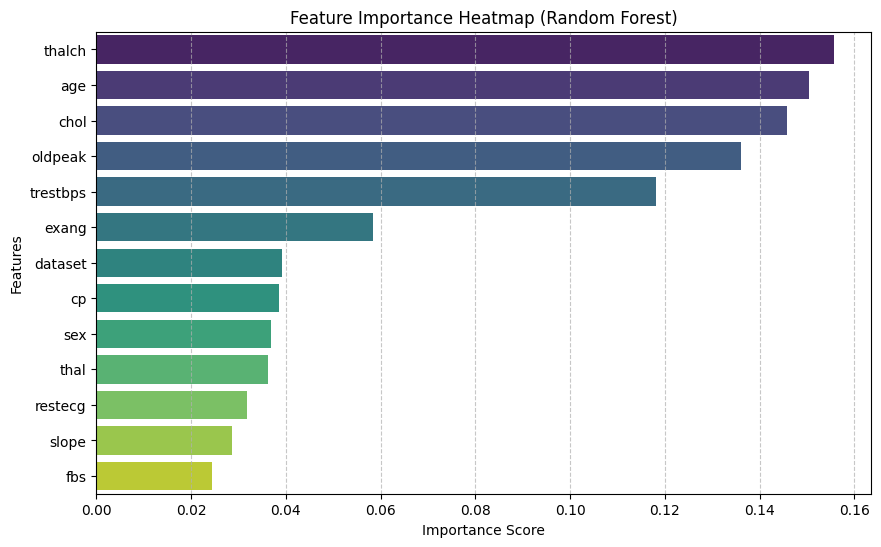

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plotting a 'Heatmap-style' Bar Plot for Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance Heatmap (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Decision Tree Visualization
We can visualize an individual tree from the Random Forest to understand the decision paths. We will limit the depth to 3 for better readability.

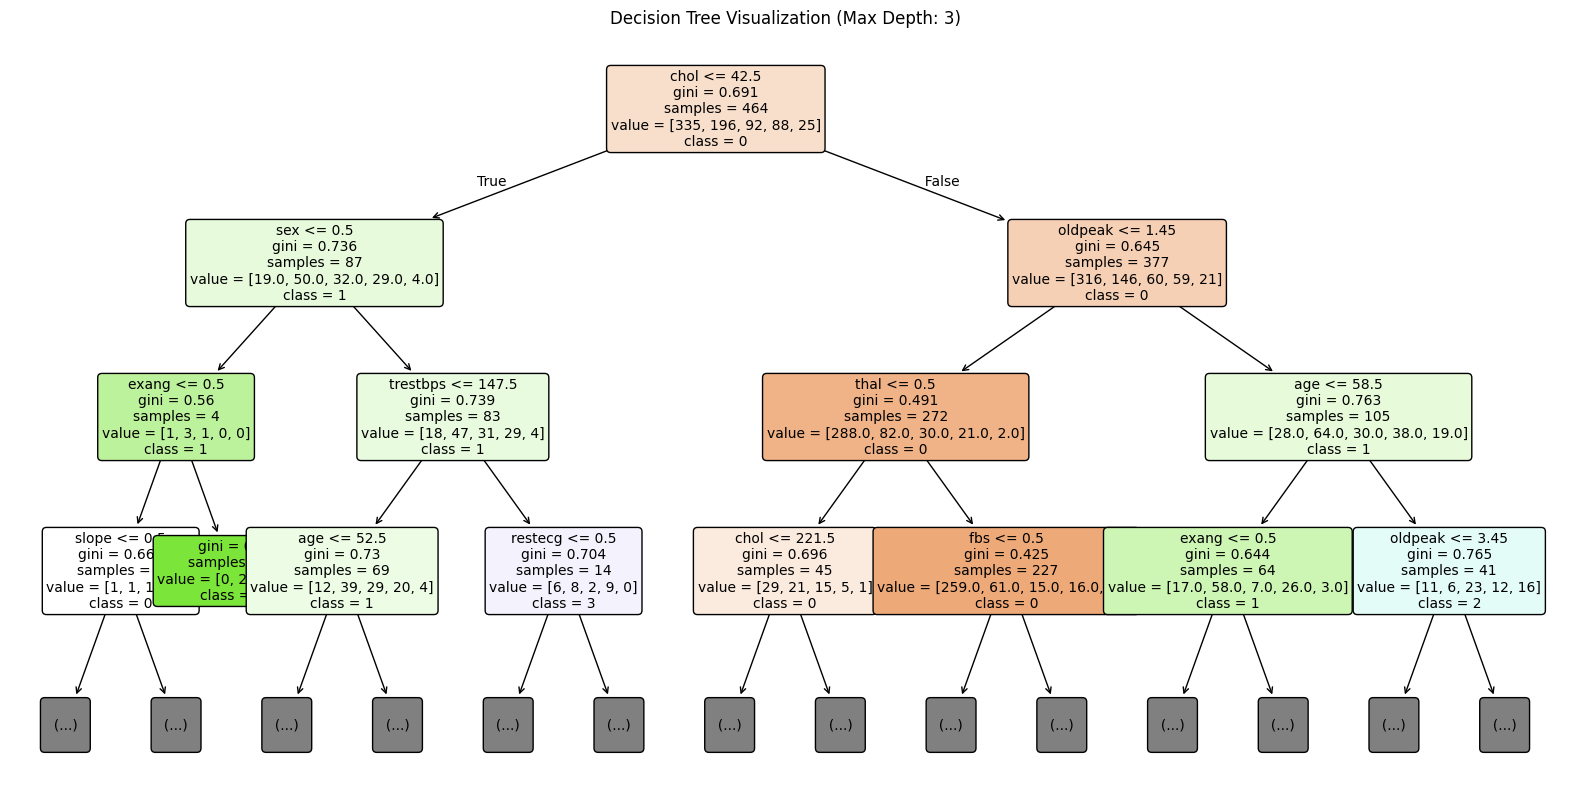

In [116]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize the first tree in the forest
plt.figure(figsize=(20, 10))
plot_tree(rf_model.estimators_[0],
          feature_names=X.columns,
          class_names=[str(i) for i in sorted(y.unique())],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)
plt.title("Decision Tree Visualization (Max Depth: 3)")
plt.show()